## AI/ML Techniques for the Statistical Inference:


### Use of Neural Network Architures in Bayesian Parameter Inference

#### Understanding the Training Dataset

![Simulation_model](./data/images/BNN/presentation_material/Simulation_model.jpg)

##### [ReionYuga](https://github.com/rajeshmondal18/ReionYuga) is a semi-Numerical simulation code for simulating 21-cm signal from IGM. It has 3 input parameters:
* $\rm M_{(h,min)}$: Minimum mass of the halos capable of ionizing the IGM
* $\rm N_{ion}$: Propotionality constant that gives the number of ionizing photos for given halo
* $\rm R_{mfp}$: Mean free path of the ionizing photon

##### Below is an example of the 21-cm brightness temperature field generated by ReionYuga simulation.

* $z = 7, \:$ $\rm M_{{(h,min)}} = 508.95 \times 10^{{8}}\;M_\odot ,\:$ $\rm N_{{ion}} = 171.58,\:$ $\rm R_{{max}} = 8.04 \:Mpc $

![HI_map](./data/HI_map.png)

In [1]:
import numpy as np
from my_code import PlotPs



/home/yash/miniconda3/envs/bsmeu-torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
parameters = np.loadtxt('./data/Parameters.txt', skiprows=1)

xHI = parameters[:,0]
input_params = parameters[:,1:]

k_values = np.loadtxt('./data/K_vals.txt',skiprows=1)
delta_PS = np.loadtxt('./data/Power_Spectrum_Normalised.txt',skiprows=1)

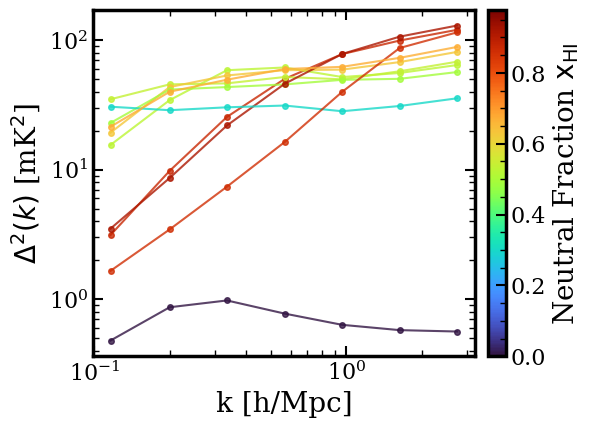

In [3]:
# Plotting the power spectrum for different xHI values

PlotPs(k_values, delta_PS, xHI, num=10)   


## Artificial Neural Network (ANN) as an Emulator

<img src = "data/images/BNN/neurons.png">
<img src = "data/images/BNN/presentation_material/training_of_ann.png" width="1200" height="550">


### Creating Training Dataset

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch

from my_code.ann import TrainANN

In [5]:
train_num = 3000
input_train = input_params[:train_num]
delta_PS_train = delta_PS[:train_num]

x_train, x_val, y_train, y_val = train_test_split(input_train, delta_PS_train, test_size=0.2, random_state=67)

In [6]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_train = x_scaler.fit_transform(x_train)
x_val   = x_scaler.transform(x_val)


In [7]:
training_data = [x_train, y_train]
validation_data = [x_val, y_val]



### Training an ANN

In [8]:
# train_loss, val_loss = TrainANN(training_data, validation_data, )

In [9]:
# len(train_loss)

In [10]:
# import matplotlib.pyplot as plt

# plt.plot(train_loss, label='Training Loss')
# plt.plot(val_loss, label='Validation Loss')
# plt.yscale('log')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# # plt.ylim(0, 500)
# plt.legend()
# plt.show()

### Using ANN for Prediction

In [11]:
# model = torch.load('./ANN_model/best_model.pth', weights_only=True)
# model["epoch"]
# model["loss"]



In [12]:
# from my_code.ann import ANN

In [13]:
# ann_model = ANN().to('cuda')
# ann_model.load_state_dict(model["model_state_dict"])
# ann_model.eval()

In [14]:
# x_test = x_val[:5]
# y_test = y_val[:5]

# x_test_tensor = torch.tensor(x_test, dtype=torch.float32).to('cuda')
# with torch.no_grad():
#     y_pred_tensor = ann_model(x_test_tensor)

# y_pred = y_pred_tensor.cpu().numpy()
# print("Predicted Power Spectrum:")
# print(y_pred)
# print("True Power Spectrum:")
# print(y_test)

# # Plotting the predicted vs true power spectrum for the test set

# for i in range(len(x_test)):
#     plt.figure(figsize=(6, 4.5))
#     plt.plot(k_values, y_test[i], label=f'True', linestyle='--', marker='o')
#     plt.plot(k_values, y_pred[i], label=f'Predicted', linestyle='-', marker='x')
#     plt.xscale('log')
#     plt.yscale('log')
#     plt.xlabel('k [h/Mpc]')
#     plt.ylabel(r'$\Delta^2(k)$ [mK$^2$]')
#     plt.legend()
#     plt.title("Neutral Fraction: {:.2f}".format(xHI[i]))
#     plt.show()


## Bayesian Neural Network (BNN) as an Emulator

<img src = "./data/images/BNN/presentation_material/ANN_vs_BNN1.jpg" width="750" height="500" >

In [15]:
from my_code import TrainBNN, BNNPredict

In [16]:
# using NUTS

bnn_model = TrainBNN(method="MCMC", training_data=training_data, hidden_layers=[16,16], num_samples=500, warmup_steps=200, path="MCMC_model")
posterior_samples = bnn_model.train()

Starting MCMC sampling...


Warmup:   0%|          | 0/700 [00:00, ?it/s]/home/yash/miniconda3/envs/bsmeu-torch/lib/python3.11/site-packages/pyro/poutine/subsample_messenger.py:70: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  result = torch.tensor(0.0, device=self.device)
Sample: 100%|██████████| 700/700 [1:01:29,  5.27s/it, step size=2.37e-04, acc. prob=0.789]

MCMC sampling completed.
Saving the model...
Best MCMC model saved at:  MCMC_model/best_mcmc_model.pth


## Bayesian Inference using ANN and BNN Emulators

<img src = "data/images/BNN/presentation_material/MCMC_with_Emulators.jpg" width = "500" height = "500">

## Simulation-Based Inference (SBI)